In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Load data
filepath = 'A01T.gdf'
raw = mne.io.read_raw_gdf(filepath, preload=True)
print(raw.info)

Extracting GDF parameters from A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


d:\Program Files\Python\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>


In [13]:
fs = raw.info['sfreq']

# Get events
events,_ = mne.events_from_annotations(raw)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


In [5]:
#Channel names
raw.ch_names

['EEG-Fz',
 'EEG-0',
 'EEG-1',
 'EEG-2',
 'EEG-3',
 'EEG-4',
 'EEG-5',
 'EEG-C3',
 'EEG-6',
 'EEG-Cz',
 'EEG-7',
 'EEG-C4',
 'EEG-8',
 'EEG-9',
 'EEG-10',
 'EEG-11',
 'EEG-12',
 'EEG-13',
 'EEG-14',
 'EEG-Pz',
 'EEG-15',
 'EEG-16',
 'EOG-left',
 'EOG-central',
 'EOG-right']

In [12]:
# Remove EOG channels and Pick EEG Chanels
raw.info['bads'] += ['EOG-right','EOG-central','EOG-left']
pick_raw = mne.pick_types (raw.info, meg=False, eeg=True, eog=False, stim=False, exclude='bads')
pick_raw

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

In [15]:
# Create epochs for motor imagery trials
# Cue events are 769, 770, 771, 772

#cue_events = [769, 770, 771, 772]
event_id= dict ({'769':7, '770':8 , '771':9, '772':10})
tmin, tmax = 2.0 , 6.0  

# Create epochs
epochs = mne.Epochs (raw, events, event_id, tmin, tmax, picks=pick_raw , preload=True, baseline= None)

print(f"\nNumber of epochs created: {len(epochs)}")
print(f"Epoch duration: {epochs.tmax - epochs.tmin} seconds")
print(f"Epoch shape: {epochs.get_data().shape} (epochs, channels, samples)")


Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
1 bad epochs dropped

Number of epochs created: 287
Epoch duration: 4.0 seconds
Epoch shape: (287, 22, 1001) (epochs, channels, samples)


In [16]:
epochs

<Epochs | 287 events (all good), 2 – 6 s (baseline off), ~48.2 MiB, data loaded,
 '769': 71
 '770': 72
 '771': 72
 '772': 72>

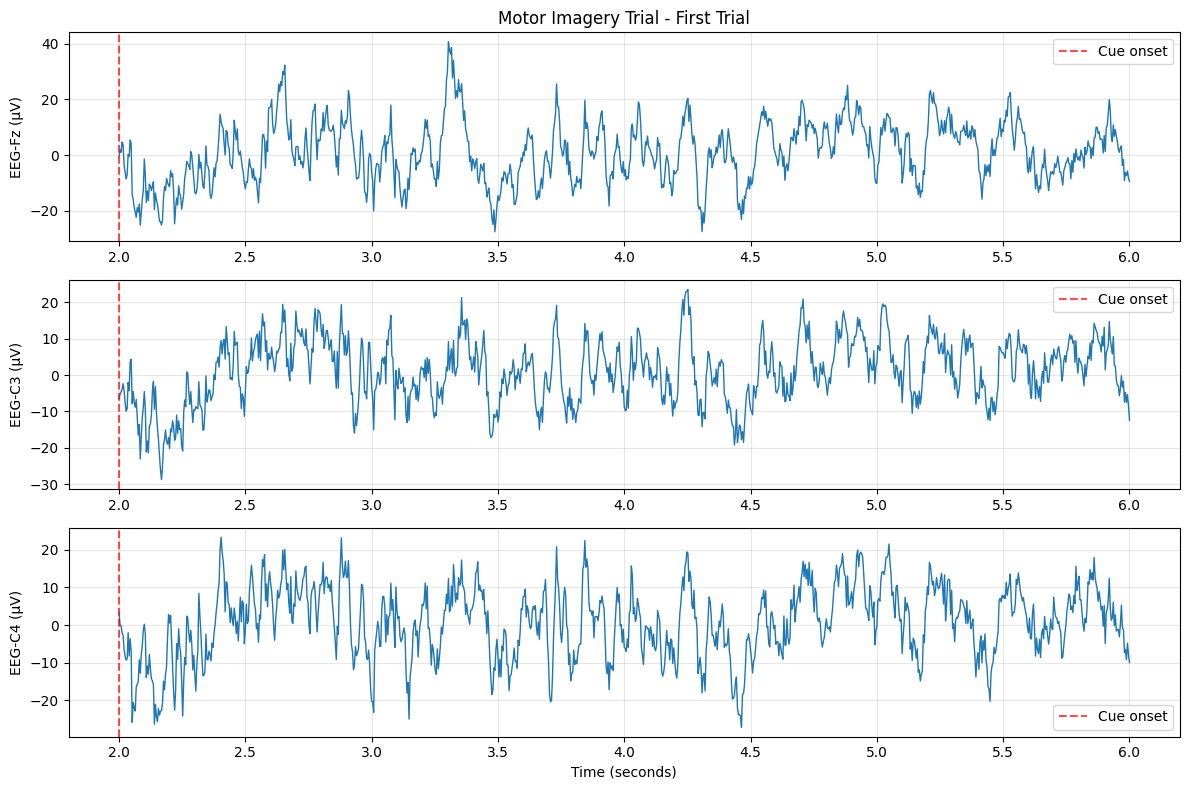

In [19]:
# Single epoch from different channels
channels = ['EEG-Fz', 'EEG-C3', 'EEG-C4']
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
time = epochs.times

# Get first epoch
first_epoch = epochs[0].get_data()[0] * 1e6  # Convert to µV

for idx, channel in enumerate(channels):
    ch_idx = epochs.ch_names.index(channel)
    trial_data = first_epoch[ch_idx, :]
    
    axes[idx].plot(time, trial_data, linewidth=1)
    axes[idx].axvline(x=2, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label='Cue onset')
    axes[idx].set_ylabel(f'{channel} (µV)')
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].set_title('Motor Imagery Trial - First Trial')
    if idx == 2:
        axes[idx].set_xlabel('Time (seconds)')
    axes[idx].legend()

plt.tight_layout()
plt.show()
